# Audio → Texto + Clasificación de Emergencias con mBERT (datos reales + contexto médico)

**Pipeline completo:**
1. El usuario graba un audio describiendo una emergencia
2. Whisper (modelo `small`) transcribe el audio a texto
3. mBERT fine-tuneado clasifica la gravedad en **tres niveles**:

| Color | Nivel | Descripción |
|-------|-------|-------------|
| 🔴 **ROJO** | MUY GRAVE | Riesgo de muerte inmediato. Si llega un segundo tarde, la persona muere. |
| 🟠 **NARANJA** | GRAVE | Situación extrema que requiere atención inmediata. |
| 🟢 **VERDE** | LEVE | Sin urgencia vital. Puede atenderse durante el día. |

---

### Estructura del notebook

| Sección | Contenido |
|---------|-----------|
| 1 | Instalación de dependencias |
| 2 | Imports y configuración |
| 3 | Carga y exploración del dataset |
| 4 | Preprocesamiento |
| 5 | Tokenización con mBERT (datos reales + contexto médico) |
| 6 | Fine-tuning con `Trainer` API |
| 7 | Evaluación del modelo |
| 8 | Predicción de nuevas llamadas |
| 9 | Pipeline Audio → Clasificación |
| 10 | ¿Por qué funciona en valenciano? |

> 💡 **Google Colab:** Activa el runtime de GPU (`Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU`) antes de ejecutar.
>
> ⚠️ **ffmpeg** debe estar instalado para que Whisper procese audios. Ver instrucciones en [ffmpeg.org](https://ffmpeg.org/download.html).

## 1. Instalación de dependencias
Ejecuta esta celda solo la primera vez.

Esta celda instala **dos grupos** de librerías:

**Para la transcripción de audio (Whisper):**
- **`openai-whisper`**: el modelo de reconocimiento de voz de OpenAI. Descarga pesos preentrenados en +99 idiomas, incluyendo español y valenciano, y convierte audio a texto mediante una arquitectura Transformer encoder-decoder.
- **`ffmpeg`** (instalación del sistema): decodifica cualquier formato de audio (mp3, m4a, wav, ogg…) antes de pasarlo a Whisper. Sin ffmpeg, Whisper solo acepta wav.

**Para la clasificación de texto (mBERT):**
- **`transformers`**: la librería de HuggingFace que contiene el modelo BERT ya preentrenado y el `Trainer`, una clase que abstrae el bucle de entrenamiento estándar de PyTorch.
- **`torch` (PyTorch)**: el motor de cálculo tensorial sobre el que corre BERT. Un *tensor* es simplemente una matriz n-dimensional optimizada para operaciones en GPU.
- **`datasets`**: permite gestionar grandes colecciones de datos de forma eficiente.
- **`scikit-learn`**: se usará para métricas (accuracy, F1) y para dividir el dataset en train/val/test.
- **`accelerate`**: librería auxiliar que `Trainer` usa por dentro para gestionar si el cómputo va a CPU o GPU sin cambiar el código.

In [3]:
# Instalación de dependencias para AMBOS módulos del pipeline

# --- Whisper (transcripción de audio) ---
!pip install openai-whisper requests --quiet

# ffmpeg: necesario para que Whisper procese formatos de audio (mp3, m4a, etc.)
# En Linux/Colab:
!apt-get install -y ffmpeg --quiet
# En macOS (descomentar si es necesario):
# !brew install ffmpeg

# --- mBERT + clasificación ---
!pip install transformers[torch] datasets accelerate scikit-learn pandas openpyxl seaborn matplotlib --quiet

# Verificamos las versiones clave instaladas
import importlib
for lib in ["whisper", "transformers", "torch", "sklearn", "pandas"]:
    try:
        mod = importlib.import_module(lib)
        print(f"{lib}: {mod.__version__}")
    except AttributeError:
        print(f"{lib}: instalado (sin __version__)")

"apt-get" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


whisper: 20250625
transformers: 5.3.0
torch: 2.7.1+cu118
sklearn: 1.3.0


c:\Users\oscar\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


pandas: 2.3.2


## 2. Imports y configuración

**Semilla aleatoria (`SEED = 42`)**  
BERT inicializa algunos pesos con números aleatorios y, durante el entrenamiento, los datos se mezclan aleatoriamente en cada epoch. Fijar la semilla en PyTorch, NumPy y Python garantiza que si vuelves a ejecutar el notebook obtendrás exactamente los mismos resultados.

**Detección de dispositivo (`DEVICE`)**  
PyTorch puede ejecutar las operaciones en CPU o en una GPU CUDA. Entrenar BERT en GPU puede ser entre 10 y 30 veces más rápido que en CPU porque las GPU están diseñadas para multiplicaciones de matrices masivas en paralelo.

**Constantes del modelo BERT**
- `MAX_LEN = 128`: BERT solo puede procesar secuencias de hasta 512 tokens. Usamos 128 porque las llamadas son frases cortas.
- `BATCH_SIZE = 16`: número de ejemplos que se procesan juntos en cada paso de entrenamiento.
- `LEARNING_RATE = 2e-5`: cuánto se ajustan los pesos en cada paso. Para fine-tuning de BERT los valores típicos son entre 1e-5 y 5e-5.
- `LABEL2ID / ID2LABEL`: BERT internamente trabaja con números. Estos diccionarios hacen la conversión en ambas direcciones.

**Sistema de tres niveles de gravedad:**
- 🔴 **MUY GRAVE**: riesgo vital inminente. Si no se actúa en segundos, la persona muere.
- 🟠 **GRAVE**: situación extrema que requiere atención inmediata, pero hay un margen mínimo de tiempo.
- 🟢 **LEVE**: sin riesgo vital. Puede atenderse durante el día.

In [4]:
import os, random, warnings, json, time, re
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset

from transformers import AutoModelForSequenceClassification
from torch.utils.data import DataLoader
import torch
import numpy as np

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback, set_seed,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)
import whisper

# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 42
set_seed(SEED); random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Dispositivo ───────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo activo: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ── Constantes del clasificador BERT ─────────────────────────────────────────
MODEL_NAME    = "bert-base-multilingual-cased"
MAX_LEN       = 128
BATCH_SIZE    = 16
NUM_EPOCHS    = 4
LEARNING_RATE = 2e-5
OUTPUT_DIR    = "./mbert_emergencias"

# ── Sistema de clasificación adaptado al Excel real ───────────────────────────
# Las etiquetas del Excel son: leve / grave / moderada
LABEL2ID   = {"leve": 0, "grave": 1, "moderada": 2}
ID2LABEL   = {0: "leve", 1: "grave", 2: "moderada"}
NUM_LABELS = 3

NIVEL_CONFIG = {
    "leve":     {"emoji": "🟢", "color": "#4CAF50", "nombre": "LEVE",     "hex_fondo": "#E8F5E9"},
    "moderada":    {"emoji": "🟠", "color": "#FF9800", "nombre": "MODERADA",    "hex_fondo": "#FFF3E0"},
    "grave": {"emoji": "🔴", "color": "#F44336", "nombre": "GRAVE", "hex_fondo": "#FFEBEE"},
}

# ── Configuración de Whisper ──────────────────────────────────────────────────
WHISPER_MODEL_SIZE = "small"
IDIOMA_AUDIO       = "es"

print("\n✓ Configuración cargada.")
print(f"  Modelo BERT:    {MODEL_NAME}")
print(f"  Modelo Whisper: {WHISPER_MODEL_SIZE}")
print(f"  Niveles:        {list(LABEL2ID.keys())}")


Dispositivo activo: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU

✓ Configuración cargada.
  Modelo BERT:    bert-base-multilingual-cased
  Modelo Whisper: small
  Niveles:        ['leve', 'grave', 'moderada']


## 3. Carga del dataset real

El dataset se carga directamente del archivo **`llamadas_emergencia.xlsx`**, que contiene **504 llamadas de emergencia** etiquetadas en tres niveles de gravedad: `leve`, `grave` y `moderada`. Cada nivel tiene exactamente 168 ejemplos, por lo que el dataset está perfectamente **balanceado**.


La función `limpiar_texto` elimina espacios múltiples y caracteres no estándar. La columna `idioma` distingue llamadas en castellano y valenciano. El campo `label` convierte la etiqueta textual en un entero que PyTorch puede procesar.


In [5]:
# ── Carga del Excel real ──────────────────────────────────────────────────────
# ⚠️  Edita sólo esta línea si el archivo está en otra ruta
EXCEL_PATH = "llamadas_emergencia.xlsx"

def limpiar_texto(texto: str) -> str:
    texto = texto.strip()
    texto = re.sub(r"\s+", " ", texto)
    return texto

df_raw = pd.read_excel(EXCEL_PATH)
df_raw = df_raw[["llamada", "idioma", "gravedad"]].dropna()
df_raw["llamada"] = df_raw["llamada"].apply(limpiar_texto)
df_raw["label"]   = df_raw["gravedad"].map(LABEL2ID)

assert df_raw["label"].isna().sum() == 0, "¡Hay etiquetas no reconocidas en el dataset!"

print(f"✓ Dataset cargado: {len(df_raw)} filas")
print(f"  Columnas: {df_raw.columns.tolist()}")
print(f"\nDistribución de clases:")
print(df_raw["gravedad"].value_counts())
print(f"\nCruce idioma × gravedad:")
print(pd.crosstab(df_raw["idioma"], df_raw["gravedad"]))
df_raw.head(8)


✓ Dataset cargado: 504 filas
  Columnas: ['llamada', 'idioma', 'gravedad', 'label']

Distribución de clases:
gravedad
leve        168
grave       168
moderada    168
Name: count, dtype: int64

Cruce idioma × gravedad:
gravedad    grave  leve  moderada
idioma                           
castellano     84    84        84
valenciano     84    84        84


,llamada,idioma,gravedad,label
0,Em sent una miqueta cansat i amb unes dècimes ...,valenciano,leve,0
1,Mi pareja tiene los labios muy hinchados y le ...,castellano,grave,1
2,"Mi perro me ha arañado el brazo, son rayaduras...",castellano,leve,0
3,"Me sangra la nariz de vez en cuando, pero para...",castellano,leve,0
4,Porte unes hores amb un mal de cap molt fort q...,valenciano,moderada,2
5,"M'han apunyalat a l'abdomen, estic perdent mol...",valenciano,grave,1
6,"Crec que m'he torçat un poc el coll dormint, e...",valenciano,leve,0
7,Me he torcido el tobillo bajando unas escalera...,castellano,leve,0


### 3.1 Exploración visual del dataset



Antes de entrenar cualquier modelo es imprescindible explorar los datos. Esta celda calcula:

- **Distribución de clases**: si hay muchos más ejemplos de una clase que de otra (*desbalance*), el modelo aprenderá a predecir siempre la mayoritaria.
- **Cruce idioma × gravedad**: comprueba que los tres niveles están representados en ambos idiomas. Si todos los `muy_grave` fueran castellano, el modelo podría aprender a clasificar por idioma en vez de por contenido médico.
- **KDE de longitud**: las llamadas muy graves tienden a ser más cortas y urgentes. Si las curvas de longitud difieren entre niveles, el modelo puede usar esa señal adicional.

Shape: (504, 4)


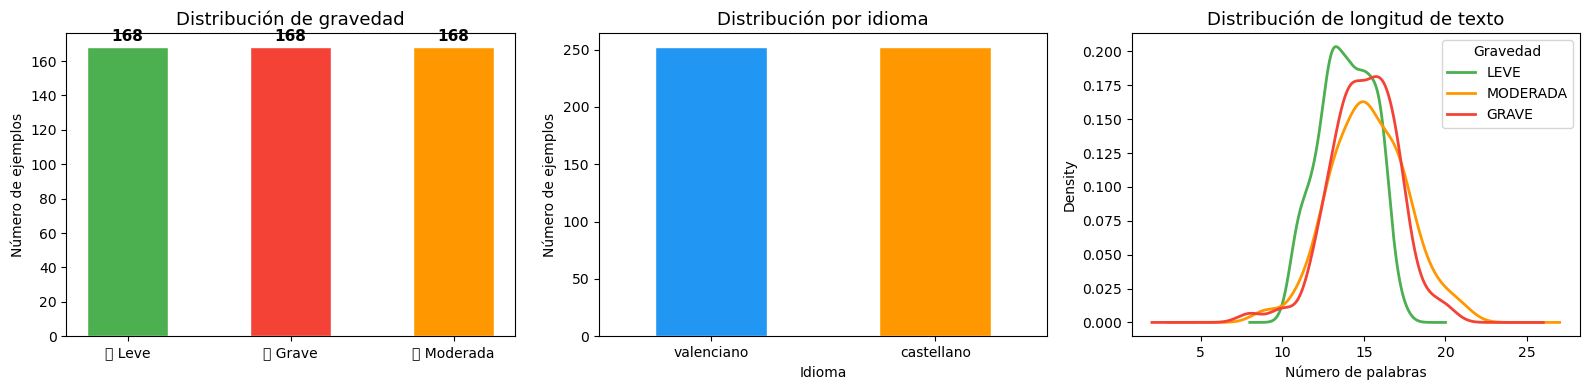


Longitud media: 14.7 palabras
Longitud máxima: 21 palabras


In [6]:
print("Shape:", df_raw.shape)
df_raw["longitud"] = df_raw["llamada"].str.split().str.len()

colores_gravedad = {n: c["color"] for n, c in NIVEL_CONFIG.items()}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

orden   = ["leve", "grave", "moderada"]
conteos = df_raw["gravedad"].value_counts().reindex(orden)
bars = axes[0].bar(
    ["🟢 Leve", "🟠 Grave", "🔴 Moderada"],
    conteos.values,
    color=[colores_gravedad[g] for g in orden],
    edgecolor="white", width=0.5
)
for bar, val in zip(bars, conteos.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
                 ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_title("Distribución de gravedad", fontsize=13)
axes[0].set_ylabel("Número de ejemplos")

df_raw["idioma"].value_counts().plot(
    kind="bar", ax=axes[1], color=["#2196F3", "#FF9800"], edgecolor="white", width=0.5
)
axes[1].set_title("Distribución por idioma", fontsize=13)
axes[1].set_xlabel("Idioma")
axes[1].set_ylabel("Número de ejemplos")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

for nivel, cfg in NIVEL_CONFIG.items():
    subset = df_raw[df_raw["gravedad"] == nivel]["longitud"]
    subset.plot(kind="kde", ax=axes[2], color=cfg["color"], linewidth=2, label=cfg["nombre"])
axes[2].set_title("Distribución de longitud de texto", fontsize=13)
axes[2].set_xlabel("Número de palabras")
axes[2].legend(title="Gravedad")

plt.tight_layout()
plt.show()

print(f"\nLongitud media: {df_raw['longitud'].mean():.1f} palabras")
print(f"Longitud máxima: {df_raw['longitud'].max()} palabras")


Al ser un dataset completamente sintético, amoldamos a nuestro parecer los datos, de esa forma no tenemos problemas de que el algoritmo aprende debido a la cantidad de datos de una clase en concreto


## 4. Preprocesamiento

Pasos aplicados:
1. **Limpieza básica** del texto (espacios, caracteres raros)
2. **Codificación de etiquetas**: `leve → 0`, `grave → 1`, `muy_grave → 2`
3. **División** train / validation / test (70 / 15 / 15) con estratificación por los tres niveles

> ⚠️ **Nota sobre la columna `idioma`:** No la concatenamos al texto porque mBERT ya detecta el idioma a través de sus embeddings. Añadirla puede introducir un atajo (*shortcut learning*) no deseado.

**Limpieza básica**: elimina espacios dobles y caracteres no deseados. No hacemos *stemming* ni eliminamos stopwords porque BERT trabaja directamente con texto en su forma natural; su tokenizador WordPiece sabe cómo tratar artículos, preposiciones y conjugaciones.

**Codificación de etiquetas**: convertimos `leve/grave/muy_grave` a `0/1/2` usando el diccionario `LABEL2ID`. Es necesario porque PyTorch solo opera con tensores numéricos.

**División estratificada**: `train_test_split` con `stratify=labels` garantiza que los tres niveles estén representados en las mismas proporciones en train, validation y test. Esto es especialmente importante con tres clases porque si `muy_grave` es la clase menos representada y no estratificamos, podría quedarse completamente fuera del test.

In [7]:
# ── División estratificada: 70% train / 15% val / 15% test ───────────────────
X          = df_raw["llamada"].values
y          = df_raw["label"].values
idiomas    = df_raw["idioma"].values
gravedades = df_raw["gravedad"].values

X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
    X, y, range(len(X)), test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(
    X_temp, y_temp, idx_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

df_test = df_raw.iloc[list(idx_test)].reset_index(drop=True)

print(f"Train:      {len(X_train):>4} ejemplos  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Validation: {len(X_val):>4} ejemplos  ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test:       {len(X_test):>4} ejemplos  ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nDistribución en test (estratificada):")
for nivel in ["leve", "grave", "moderada"]:
    cfg = NIVEL_CONFIG[nivel]
    n   = (df_test["gravedad"] == nivel).sum()
    print(f"  {cfg['emoji']} {cfg['nombre']:<12}: {n}")


Train:       352 ejemplos  (70%)
Validation:   76 ejemplos  (15%)
Test:         76 ejemplos  (15%)

Distribución en test (estratificada):
  🟢 LEVE        : 25
  🔴 GRAVE       : 26
  🟠 MODERADA    : 25


## 5. Tokenización con mBERT

**`AutoTokenizer.from_pretrained(MODEL_NAME)`** descarga el vocabulario WordPiece de mBERT: ~120.000 subpalabras compartidas entre los 104 idiomas del preentrenamiento.

**WordPiece**: en lugar de tokenizar por palabras completas (lo que implicaría un vocabulario imposiblemente grande), BERT divide cada palabra en subpalabras frecuentes. Por ejemplo:
- `"inconsciente"` → `["in", "##con", "##sci", "##ente"]`
- `"hemorràgia"` (valenciano) → `["hemor", "##ràg", "##ia"]`

Esto permite manejar palabras nuevas o poco frecuentes descomponiéndolas en partes conocidas.

**Tokens especiales:**
- `[CLS]` al inicio: su vector final en la última capa será el resumen semántico de toda la frase, usado para clasificar.
- `[SEP]` al final: marca el fin de la secuencia.
- `[PAD]`: rellena secuencias cortas hasta `MAX_LEN` para que los batches tengan tamaño uniforme.

**`attention_mask`**: tensor de 0s y 1s que indica a BERT qué tokens son reales (1) y cuáles son padding (0), para que no los tenga en cuenta en el cálculo de la atención.

In [8]:
print(f"Descargando tokenizador de '{MODEL_NAME}'...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"✓ Tokenizador cargado. Vocab size: {tokenizer.vocab_size:,}")

ejemplo = "Mi madre no respira y tiene los labios morados"
tokens  = tokenizer.tokenize(ejemplo)
print(f"\nEjemplo de tokenización:")
print(f"  Texto:  '{ejemplo}'")
print(f"  Tokens: {tokens}")
print(f"  Total:  {len(tokens)} tokens")

class EmergencyDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True,
            max_length=MAX_LEN, return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }

train_dataset = EmergencyDataset(X_train, y_train, tokenizer)
val_dataset   = EmergencyDataset(X_val,   y_val,   tokenizer)
test_dataset  = EmergencyDataset(X_test,  y_test,  tokenizer)

print(f"\nTamaño de un ejemplo tokenizado:")
sample = train_dataset[0]
for k, v in sample.items():
    print(f"  {k}: shape={v.shape}, dtype={v.dtype}")


Descargando tokenizador de 'bert-base-multilingual-cased'...


✓ Tokenizador cargado. Vocab size: 119,547

Ejemplo de tokenización:
  Texto:  'Mi madre no respira y tiene los labios morados'
  Tokens: ['Mi', 'madre', 'no', 'resp', '##ira', 'y', 'tiene', 'los', 'lab', '##ios', 'mora', '##dos']
  Total:  12 tokens

Tamaño de un ejemplo tokenizado:
  input_ids: shape=torch.Size([33]), dtype=torch.int64
  attention_mask: shape=torch.Size([33]), dtype=torch.int64
  labels: shape=torch.Size([]), dtype=torch.int64


## 6. Fine-tuning con Trainer API

### Arquitectura

```
[CLS] token_1 token_2 ... token_n [SEP]
      ↓
   mBERT encoder (12 capas Transformer)
      ↓
  Representación [CLS]  (768 dimensiones)
      ↓
  Capa Dense (768 → 3)  +  Softmax
      ↓
  P(leve)  P(grave)  P(muy_grave)
```

La única diferencia respecto a la versión binaria es que la capa de salida ahora tiene **3 neuronas** en vez de 2.



Esta función recibe los `logits` crudos del modelo (tres números por ejemplo, uno para cada clase) y las etiquetas reales, y devuelve las métricas de evaluación.

**`np.argmax(logits, axis=-1)`**: toma el índice del valor más alto entre los tres logits. Si el logit de `muy_grave` es el mayor, predice ese nivel.

**Métricas calculadas:**
- **Accuracy**: porcentaje total de predicciones correctas.
- **Precision / Recall / F1**: con `average="macro"` se calcula la media no ponderada entre las tres clases. Esto da el mismo peso a `muy_grave` que a `leve`, aunque tenga menos ejemplos — lo cual es correcto porque en emergencias los errores en `muy_grave` son los más costosos.

En este dominio, el **recall de `muy_grave`** es la métrica más crítica: un falso negativo (clasificar como leve o grave algo muy grave) puede costar una vida.

In [9]:
def compute_metrics(eval_pred):
    """Calcula accuracy, precision, recall y F1 macro para clasificación multiclase."""
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)

    # average="macro": media no ponderada entre clases (igual peso para muy_grave)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, predictions)
    return {
        "accuracy":  round(acc, 4),
        "precision": round(precision, 4),
        "recall":    round(recall, 4),
        "f1":        round(f1, 4),
    }

`AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)` hace dos cosas:

1. **Descarga los pesos preentrenados** de `bert-base-multilingual-cased` (~700 MB). Estos pesos contienen el conocimiento lingüístico adquirido durante meses de entrenamiento sobre Wikipedia en 104 idiomas.

2. **Añade una capa de clasificación nueva** encima del encoder: una capa densa lineal de 768 → **3** neuronas (una por nivel de gravedad). Esta capa se inicializa aleatoriamente.

Durante el fine-tuning, **todos los pesos son entrenables** con un learning rate muy bajo (2e-5) para no destruir el conocimiento preentrenado.

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,     # 3 clases: leve, grave, muy_grave
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales:     {total_params:,}")
print(f"Parámetros entrenables: {trainable:,}")
print(f"Parámetros congelados:  {total_params - trainable:,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parámetros totales:     177,855,747
Parámetros entrenables: 177,855,747
Parámetros congelados:  0


**`TrainingArguments`** centraliza todos los hiperparámetros:

- **`warmup_ratio=0.1`**: durante el primer 10% de los pasos, el learning rate sube gradualmente desde 0 hasta 2e-5. Evita que los gradientes iniciales ruidosos destruyan los pesos de BERT.
- **`weight_decay=0.01`**: regularización L2 para prevenir overfitting.
- **`fp16=(DEVICE == "cuda")`**: mixed precision (float16) en GPU, más rápido y con menos memoria.
- **`EarlyStoppingCallback(patience=2)`**: si el F1 macro en validación no mejora en 2 epochs, se detiene el entrenamiento y se recupera el mejor modelo.

**`Trainer`** orquesta el bucle completo: forward pass → Cross-Entropy loss → backpropagation → actualización AdamW.

In [11]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir=f"{OUTPUT_DIR}/logs",
    logging_steps=20,
    fp16=(DEVICE == "cuda"),
    seed=SEED,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Configuración de entrenamiento lista.")
print(f"Steps por epoch: {len(train_dataset) // BATCH_SIZE}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Configuración de entrenamiento lista.
Steps por epoch: 22


En cada paso del bucle de entrenamiento:

1. **Forward pass**: los tokens pasan por las 12 capas Transformer de BERT. Cada capa aplica *Self-Attention*: cada token pondera cuánto debe fijarse en los demás. El resultado es que el vector del token `[CLS]` incorpora contexto global de toda la llamada.

2. **Cross-Entropy Loss** (para 3 clases): compara los tres logits con la etiqueta real usando la fórmula `-log(P(clase_real))`. Si el modelo predice `leve` con 90% pero la etiqueta es `muy_grave`, la pérdida es alta.

3. **Backward pass (backpropagation)**: calcula el gradiente de la pérdida respecto a cada uno de los 110M parámetros del modelo.

4. **AdamW**: actualiza los pesos en la dirección opuesta al gradiente, ajustado por el historial de gradientes pasados y con weight decay desacoplado.

In [12]:
# ⏳ Este paso tarda ~3-8 min en GPU de Colab, ~20-40 min en CPU
print("Iniciando entrenamiento...")
train_result = trainer.train()

print("\n✅ Entrenamiento completado")
print(f"   Tiempo total:       {train_result.metrics['train_runtime']:.1f}s")
print(f"   Samples/segundo:    {train_result.metrics['train_samples_per_second']:.1f}")
print(f"   Loss final (train): {train_result.metrics['train_loss']:.4f}")

Iniciando entrenamiento...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.098386,1.021073,0.407900,0.406500,0.413300,0.302300
2,0.920601,0.692847,0.671100,0.796500,0.677900,0.611200
3,0.592990,0.407875,0.881600,0.889900,0.882600,0.882200
4,0.350321,0.352744,0.907900,0.915500,0.908700,0.907900


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✅ Entrenamiento completado
   Tiempo total:       70.5s
   Samples/segundo:    20.0
   Loss final (train): 0.6982


In [13]:
# Guardamos el modelo y el tokenizador para reutilizarlos sin reentrenar
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Modelo guardado en: {OUTPUT_DIR}/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en: ./mbert_emergencias/


`trainer.state.log_history` es una lista de diccionarios que el `Trainer` acumula durante el entrenamiento.

**Curva de pérdida (training loss)**: debe descender con el tiempo. Si desciende muy rápido y luego sube, hay *overfitting*.

**Curvas de validación (F1 macro y Accuracy)**: deben subir. El F1 macro es especialmente informativo porque pondera igual las tres clases. Si el F1 macro se estanca pero el accuracy sigue subiendo, el modelo probablemente está prediciendo bien `leve` (clase mayoritaria) pero fallando en `muy_grave`. El `EarlyStoppingCallback` actúa en ese momento.

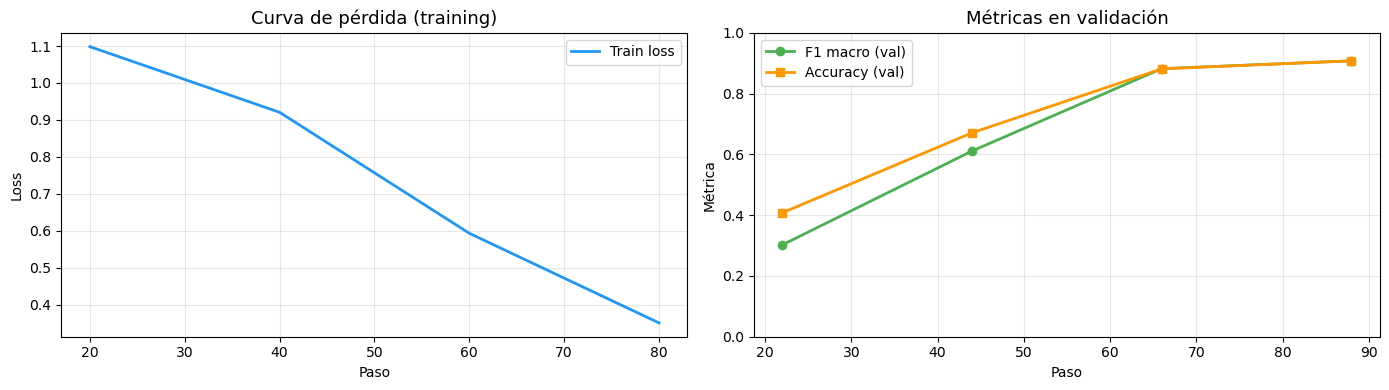

In [14]:
history   = trainer.state.log_history

train_loss = [(x["step"], x["loss"])          for x in history if "loss" in x and "eval_loss" not in x]
eval_f1    = [(x["step"], x["eval_f1"])        for x in history if "eval_f1" in x]
eval_acc   = [(x["step"], x["eval_accuracy"])  for x in history if "eval_accuracy" in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

if train_loss:
    steps, losses = zip(*train_loss)
    axes[0].plot(steps, losses, color="#2196F3", linewidth=2, label="Train loss")
axes[0].set_title("Curva de pérdida (training)", fontsize=13)
axes[0].set_xlabel("Paso")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

if eval_f1:
    steps_f1, f1s   = zip(*eval_f1)
    steps_acc, accs = zip(*eval_acc)
    axes[1].plot(steps_f1,  f1s,  color="#4CAF50", linewidth=2, marker="o", label="F1 macro (val)")
    axes[1].plot(steps_acc, accs, color="#FF9800", linewidth=2, marker="s", label="Accuracy (val)")
axes[1].set_title("Métricas en validación", fontsize=13)
axes[1].set_xlabel("Paso")
axes[1].set_ylabel("Métrica")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Evaluación del modelo

Evaluamos sobre el conjunto de **test** (datos nunca vistos durante el entrenamiento).

`trainer.evaluate(test_dataset)` hace un **forward pass** por todos los ejemplos del test (sin calcular gradientes, con `torch.no_grad()`) y llama a `compute_metrics`.

La **matriz de confusión** es especialmente informativa con tres clases porque muestra exactamente qué tipos de errores comete el modelo:
- ¿Confunde `muy_grave` con `grave`? (error grave pero no catastrófico)
- ¿Confunde `muy_grave` con `leve`? (error potencialmente mortal)
- ¿Confunde `leve` con `muy_grave`? (falsa alarma, costosa en recursos)

El `classification_report` da precision, recall y F1 **por cada uno de los tres niveles** por separado, revelando si el modelo tiene un punto débil en alguna clase específica.

In [ ]:
# Cargar modelo guardado
model = AutoModelForSequenceClassification.from_pretrained(OUTPUT_DIR)
model.to(DEVICE)
model.eval()

# Evaluación manual sin Trainer
loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"]

        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        preds  = torch.argmax(logits, dim=-1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Métricas
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

acc                        = accuracy_score(all_labels, all_preds)
precision, recall, f1, _   = precision_recall_fscore_support(all_labels, all_preds, average="macro", zero_division=0)

print(f"\n Resultados en TEST:")
print(f"  Accuracy:        {acc:.4f}")
print(f"  Precision macro: {precision:.4f}")
print(f"  Recall macro:    {recall:.4f}")
print(f"  F1 macro:        {f1:.4f}")

print("\n Reporte por clase:")
print(classification_report(all_labels, all_preds, target_names=list(LABEL2ID.keys())))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


📊 Resultados en TEST:
  Accuracy:        0.8553
  Precision macro: 0.8739
  Recall macro:    0.8533
  F1 macro:        0.8541

📋 Reporte por clase:
              precision    recall  f1-score   support

        leve       1.00      0.84      0.91        25
       grave       0.76      1.00      0.87        26
    moderada       0.86      0.72      0.78        25

    accuracy                           0.86        76
   macro avg       0.87      0.85      0.85        76
weighted avg       0.87      0.86      0.85        76



El modelo alcanza un 85.5% de accuracy en el conjunto de test, con un F1 macro de 0.854, lo que indica un rendimiento sólido y equilibrado entre las tres clases. La clase leve es la mejor clasificada, con precisión perfecta (1.00) y un F1 de 0.91, lo que significa que el modelo nunca etiqueta erróneamente como leve una llamada que no lo es. La clase grave tiene el recall más alto (1.00), es decir, el modelo detecta todos los casos graves, aunque a costa de algunas falsas alarmas. El punto más débil es moderada, con un recall de 0.72 y un F1 de 0.78, lo que indica que aproximadamente 1 de cada 4 llamadas de alta gravedad se clasifica incorrectamente en otra categoría. En un contexto de emergencias sanitarias, este es el error más crítico a reducir, ya que implica que algunas situaciones urgentes podrían recibir una respuesta menos prioritaria.


📋 Reporte detallado por clase:
              precision    recall  f1-score   support

        leve       1.00      0.84      0.91        25
       grave       0.76      1.00      0.87        26
   muy_grave       0.86      0.72      0.78        25

    accuracy                           0.86        76
   macro avg       0.87      0.85      0.85        76
weighted avg       0.87      0.86      0.85        76



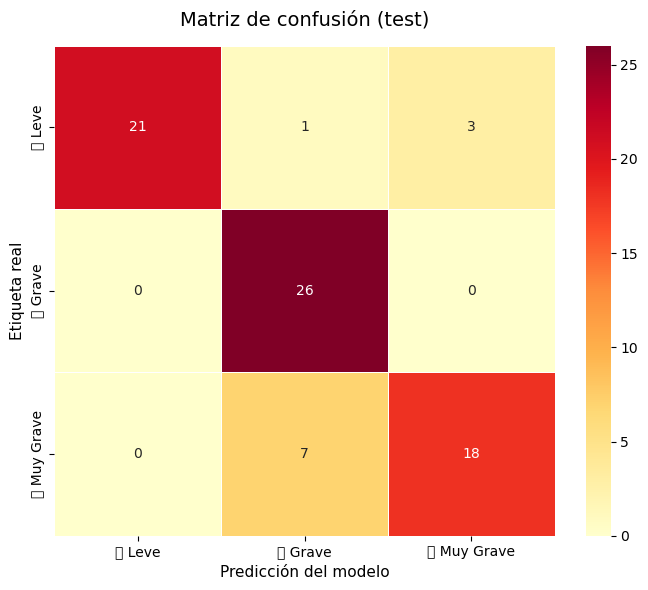

In [16]:
# Obtener predicciones en el conjunto de test
preds_output = trainer.predict(test_dataset)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = y_test

nombres_niveles = ["🟢 Leve", "🟠 Grave", "🔴 Muy Grave"]

# Reporte detallado por clase
print("\n📋 Reporte detallado por clase:")
print(classification_report(
    y_true, y_pred,
    target_names=["leve", "grave", "muy_grave"]
))

# Matriz de confusión con colores del sistema de emergencias
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlOrRd",
    xticklabels=nombres_niveles,
    yticklabels=nombres_niveles,
    ax=ax, linewidths=0.5
)
ax.set_title("Matriz de confusión (test)", fontsize=14, pad=15)
ax.set_ylabel("Etiqueta real", fontsize=11)
ax.set_xlabel("Predicción del modelo", fontsize=11)
plt.tight_layout()
plt.show()


## 8. Predicción de nuevas llamadas de texto

Función lista para producción: toma un texto y devuelve el nivel de gravedad con los tres colores del sistema.

Esta función encapsula el **pipeline de inferencia** completo:

1. `model.eval()`: desactiva el *Dropout* (capas que apagan aleatoriamente neuronas durante el entrenamiento). En modo evaluación el modelo es determinista.

2. `torch.no_grad()`: desactiva el cálculo del grafo de gradientes, reduciendo el consumo de memoria a la mitad.

3. `torch.softmax(logits, dim=-1)`: convierte los **tres** logits crudos en probabilidades que suman 1. Por ejemplo, logits `[1.2, 2.1, 5.8]` → probabilidades `[0.02, 0.04, 0.94]` → predice `muy_grave` con 94% de confianza.

4. `np.argmax(probs)`: selecciona la clase con mayor probabilidad.

El resultado incluye el emoji y color del nivel clasificado para hacer el output visualmente intuitivo en un contexto de operaciones de emergencia.

In [17]:
def predecir(texto: str, model=model, tokenizer=tokenizer, device=DEVICE) -> dict:
    """
    Predice el nivel de gravedad de una llamada de emergencia.
    Niveles: leve (0) / grave (1) / moderada (2)
    """
    model.eval()
    inputs = tokenizer(
        texto, return_tensors="pt",
        truncation=True, padding=True, max_length=MAX_LEN
    ).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits

    probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    pred  = int(np.argmax(probs))
    label = ID2LABEL[pred]
    cfg   = NIVEL_CONFIG[label]

    return {
        "texto":         texto,
        "label":         label,
        "nombre_nivel":  cfg["nombre"],
        "emoji":         cfg["emoji"],
        "color":         cfg["color"],
        "confianza":     f"{probs[pred]*100:.1f}%",
        "prob_leve":     f"{probs[0]*100:.1f}%",
        "prob_grave":    f"{probs[1]*100:.1f}%",
        "prob_moderada": f"{probs[2]*100:.1f}%",
    }


In [18]:
# ── Batería de pruebas con los tres niveles ───────────────────────────────────
nuevas_llamadas = [
    ("Es", "leve",     "Tengo dolor de barriga, por ahora puedo aguantar"),
    ("Es", "leve",     "Me he dado un golpe en la espinilla, tengo un moratón pero puedo caminar"),
    ("Es", "grave",    "Ha habido un accidente, hay heridos conscientes pero con dolor intenso"),
    ("Es", "grave",    "Hay un incendio en el piso de arriba, todos han evacuado"),
    ("Es", "grave", "Mi madre no responde, está tirada en el suelo y apenas respira"),
    ("Es", "moderada", "Tengo un dolor aplastante en el pecho y el brazo izquierdo no lo noto"),
    ("Va", "leve",     "Em fa mal el cap des d'aquest matí però puc fer vida normal"),
    ("Va", "leve",     "Porte dos malalt, crec que és un refredat"),
    ("Va", "grave",    "Hi ha hagut un accident, un conductor té el cap sangrant"),
    ("Va", "grave", "La meua parella ha perdut el coneixement i no respon a res"),
    ("Va", "grave", "El meu pare no respira i té els llavis blaus"),
]

results = []
for lang, verdad, texto in nuevas_llamadas:
    r  = predecir(texto)
    ok = "✅" if r["label"] == verdad else "❌"
    results.append({
        "Idioma":      "Castellano" if lang == "Es" else "Valenciano",
        "Real":        verdad,
        "Pred":        f"{r['emoji']} {r['nombre_nivel']}",
        "Confianza":   r["confianza"],
        "P(leve)":     r["prob_leve"],
        "P(grave)":    r["prob_grave"],
        "P(moderada)": r["prob_moderada"],
        "OK":          ok,
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))


    Idioma     Real       Pred Confianza P(leve) P(grave) P(moderada) OK
Castellano     leve     🟢 LEVE     75.3%   75.3%     3.2%       21.5%  ✅
Castellano     leve     🟢 LEVE     91.8%   91.8%     2.5%        5.7%  ✅
Castellano    grave    🔴 GRAVE     79.0%    1.6%    79.0%       19.4%  ✅
Castellano    grave    🔴 GRAVE     85.0%    2.8%    85.0%       12.2%  ✅
Castellano    grave    🔴 GRAVE     89.0%    2.7%    89.0%        8.3%  ✅
Castellano moderada 🟠 MODERADA     59.7%    2.9%    37.4%       59.7%  ✅
Valenciano     leve     🟢 LEVE     84.8%   84.8%     2.7%       12.5%  ✅
Valenciano     leve     🟢 LEVE     88.9%   88.9%     2.3%        8.8%  ✅
Valenciano    grave    🔴 GRAVE     86.0%    2.6%    86.0%       11.4%  ✅
Valenciano    grave    🔴 GRAVE     78.4%    4.5%    78.4%       17.1%  ✅
Valenciano    grave    🔴 GRAVE     86.2%    1.8%    86.2%       12.0%  ✅


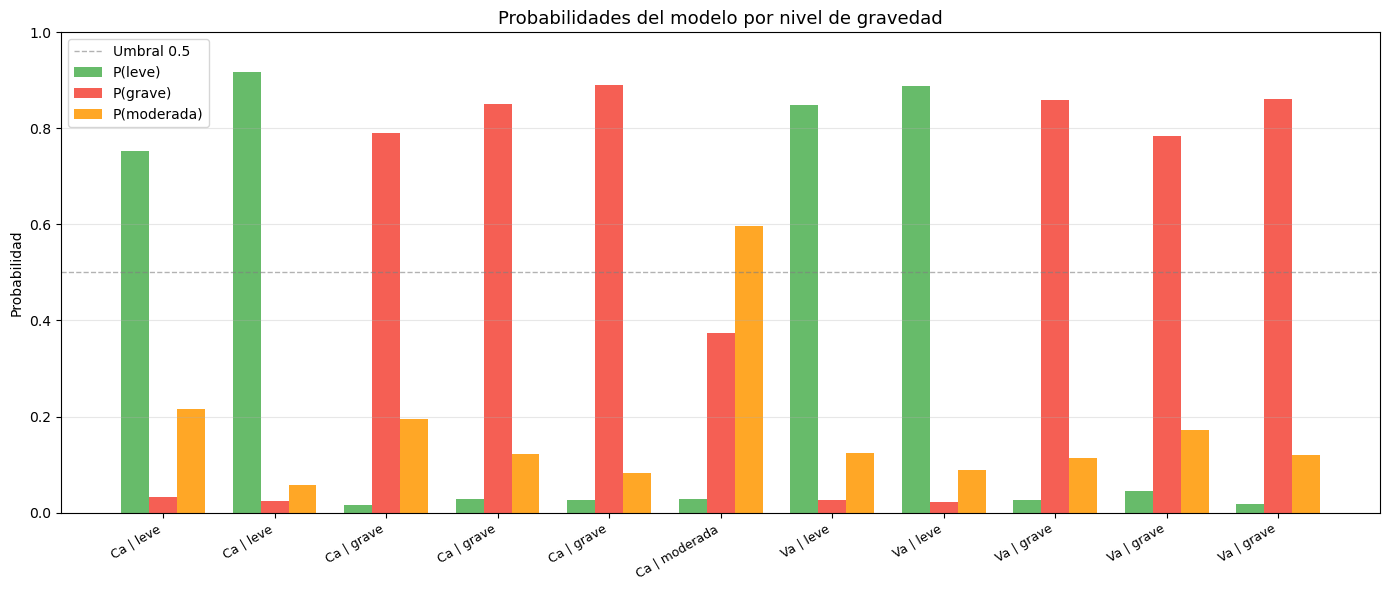

In [19]:
fig, ax = plt.subplots(figsize=(14, 6))

etiquetas  = [f"{r['Idioma'][:2]} | {r['Real']}" for _, r in df_results.iterrows()]
p_leve     = [float(r["P(leve)"].replace("%",""))/100     for _, r in df_results.iterrows()]
p_grave    = [float(r["P(grave)"].replace("%",""))/100    for _, r in df_results.iterrows()]
p_mod      = [float(r["P(moderada)"].replace("%",""))/100 for _, r in df_results.iterrows()]

x = np.arange(len(etiquetas))
w = 0.25
ax.bar(x - w,  p_leve,  w, label="P(leve)",     color=NIVEL_CONFIG["leve"]["color"],     alpha=0.85)
ax.bar(x,      p_grave, w, label="P(grave)",    color=NIVEL_CONFIG["grave"]["color"],    alpha=0.85)
ax.bar(x + w,  p_mod,   w, label="P(moderada)", color=NIVEL_CONFIG["moderada"]["color"], alpha=0.85)
ax.axhline(0.5, linestyle="--", color="gray", linewidth=1, alpha=0.6, label="Umbral 0.5")
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel("Probabilidad")
ax.set_title("Probabilidades del modelo por nivel de gravedad", fontsize=13)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Pipeline Audio → Clasificación + Búsqueda de Contexto Médico

El pipeline completo hace **tres cosas** de forma encadenada:

1. **Transcribe** el audio con Whisper (`small`)
2. **Clasifica** la gravedad con mBERT fine-tuneado sobre los datos reales
3. **Busca en Wikipedia** información médica relevante para dar **pistas clave al equipo de ambulancia** antes de llegar al lugar

```
Audio (.mp4 / .m4a / .wav)
        ↓
  [Whisper small]         → texto transcrito
        ↓
  [mBERT fine-tuneado]    → nivel de gravedad
        ↓
  [Wikipedia API (es)]    → resumen médico
        ↓
  Informe para la ambulancia
```

La función `extraer_terminos_medicos` extrae palabras clave de la llamada (síntomas, partes del cuerpo, acciones) filtrando stopwords. Con esos términos lanza dos peticiones a la **API REST pública de Wikipedia en español**: primero una búsqueda de título, luego el resumen del artículo más relevante. No requiere clave API.


###  Carga de Whisper

Whisper es un modelo Transformer encoder-decoder entrenado por OpenAI sobre 680.000 horas de audio en 99 idiomas. El encoder procesa espectrogramas de mel (representación frecuencia-tiempo del audio) y el decoder genera texto token a token.

El modelo `small` (461 MB) tiene 244M parámetros y es el mejor equilibrio calidad/velocidad para español. En CPU una llamada de 30 segundos tarda ~10-20 segundos en transcribirse; en GPU es casi instantáneo.

**`fp16=False`**: desactiva la precisión reducida en CPU para evitar errores de compatibilidad. En GPU se puede poner `fp16=True` para mayor velocidad.

In [20]:
print(f"Cargando modelo Whisper '{WHISPER_MODEL_SIZE}'...")
print("(La primera vez descarga ~461 MB; las siguientes es instantáneo)")
inicio = time.time()

modelo_whisper = whisper.load_model(WHISPER_MODEL_SIZE)

print(f"✓ Modelo Whisper cargado en {time.time() - inicio:.1f} segundos.")

Cargando modelo Whisper 'small'...
(La primera vez descarga ~461 MB; las siguientes es instantáneo)
✓ Modelo Whisper cargado en 7.5 segundos.


In [25]:
import requests

# ─────────────────────────────────────────────────────────────────────────────

def transcribir_audio(ruta_audio: str) -> dict:
    """Transcribe un archivo de audio a texto usando Whisper."""
    if not os.path.isfile(ruta_audio):
        return {"exito": False, "texto": f"Archivo no encontrado: '{ruta_audio}'"}
    try:
        resultado = modelo_whisper.transcribe(ruta_audio, language=IDIOMA_AUDIO, fp16=False)
        return {"exito": True, "texto": resultado["text"].strip()}
    except Exception as e:
        return {"exito": False, "texto": f"Error en transcripción: {e}"}


def extraer_terminos_medicos(texto: str, nivel: str) -> str:
    """Extrae palabras clave del texto de la llamada para buscar en Wikipedia."""
    stopwords_es = {
        "me", "mi", "el", "la", "los", "las", "un", "una", "de", "en", "que",
        "es", "se", "no", "ha", "con", "su", "al", "del", "le", "por", "lo",
        "como", "pero", "muy", "más", "ya", "está", "tiene", "hay", "tengo",
        "soy", "creo", "acabo", "llevo", "días", "horas", "minutos", "hace",
        "desde", "para", "bien", "esto", "esta", "otro", "cuando", "poco",
    }
    palabras = re.findall(r'\b[a-záéíóúüñ]{4,}\b', texto.lower())
    terminos = [p for p in palabras if p not in stopwords_es]

    contexto = {
        "moderada": "emergencia médica urgente síntomas graves",
        "grave":    "urgencia médica atención inmediata",
        "leve":     "síntomas leves primeros auxilios",
    }
    query = " ".join(terminos[:4]) + " " + contexto.get(nivel, "emergencia")
    return query.strip()


def buscar_wikipedia(query: str, max_chars: int = 900) -> dict:
    """
    Busca en Wikipedia en español y devuelve el resumen del artículo más relevante.
    Usa la API pública de Wikipedia — no requiere clave de API.
    """
    SEARCH_URL  = "https://es.wikipedia.org/w/api.php"
    SUMMARY_URL = "https://es.wikipedia.org/api/rest_v1/page/summary/"

    try:
        # Paso 1: buscar el título del artículo más relevante
        r_search = requests.get(SEARCH_URL, params={
            "action": "query", "list": "search",
            "srsearch": query, "srlimit": 1, "format": "json",
        }, timeout=8)
        r_search.raise_for_status()
        resultados = r_search.json().get("query", {}).get("search", [])

        if not resultados:
            return {"exito": False, "titulo": "", "resumen": "Sin resultados.", "url": ""}

        titulo = resultados[0]["title"]

        # Paso 2: obtener resumen del artículo
        r_sum = requests.get(SUMMARY_URL + requests.utils.quote(titulo), timeout=8)
        r_sum.raise_for_status()
        data   = r_sum.json()

        resumen = data.get("extract", "")
        if len(resumen) > max_chars:
            resumen = resumen[:max_chars]
            corte   = resumen.rfind(".")
            if corte > max_chars // 2:
                resumen = resumen[:corte + 1]

        return {
            "exito":   True,
            "titulo":  data.get("title", titulo),
            "resumen": resumen,
            "url":     data.get("content_urls", {}).get("desktop", {}).get("page", ""),
        }

    except requests.exceptions.Timeout:
        return {"exito": False, "titulo": "", "resumen": "Timeout al consultar Wikipedia.", "url": ""}
    except Exception as e:
        return {"exito": False, "titulo": "", "resumen": f"Error: {e}", "url": ""}


def procesar_emergencia(ruta_audio: str) -> dict:
    """
    Pipeline completo:
      1. Transcripción con Whisper
      2. Clasificación de gravedad con mBERT fine-tuneado
      3. Búsqueda de contexto médico en Wikipedia (es)
    """
    print(f"Procesando: {ruta_audio}")
    print("─" * 60)

    # Paso 1: Transcripción
    print("[1/3] Transcribiendo audio con Whisper...")
    transcripcion = transcribir_audio(ruta_audio)
    if not transcripcion["exito"]:
        print(f"✗ Error: {transcripcion['texto']}")
        return {"error": transcripcion["texto"]}
    texto = transcripcion["texto"]
    print(f'✓ Transcripción: "{texto}"\n')

    # Paso 2: Clasificación
    print("[2/3] Clasificando gravedad con mBERT fine-tuneado...")
    clasificacion = predecir(texto)
    nivel = clasificacion["label"]
    cfg   = NIVEL_CONFIG[nivel]
    print(f"✓ Nivel detectado: {cfg['emoji']} {cfg['nombre']} ({clasificacion['confianza']})\n")

    # Paso 3: Búsqueda Wikipedia
    print("[3/3] Buscando contexto médico en Wikipedia...")
    query = extraer_terminos_medicos(texto, nivel)
    wiki  = buscar_wikipedia(query)
    if wiki["exito"]:
        print(f"✓ Artículo encontrado: '{wiki['titulo']}'\n")
    else:
        print(f"  (Sin resultados: {wiki['resumen']})\n")

    # ── Informe final ──────────────────────────────────────────────────────────
    descripciones = {
        "moderada": "⚠️  ATENCIÓN URGENTE — situación de alta gravedad médica.",
        "grave":    "⚠️  ATENCIÓN INMEDIATA — desplegar recursos de forma urgente.",
        "leve":     "ℹ️  SIN URGENCIA VITAL — puede atenderse durante el día.",
    }

    print()
    print("=" * 60)
    print("        INFORME PARA EL EQUIPO DE AMBULANCIA")
    print("=" * 60)
    print(f"  {cfg['emoji']}  Nivel: {cfg['nombre']}   |   Confianza: {clasificacion['confianza']}")
    print()
    print(f"  {descripciones[nivel]}")
    print()
    print(f"  📞 Llamada transcrita:")
    print(f'  "{texto}"')
    print()
    print(f"  Probabilidades:")
    print(f"    🟢 Leve:     {clasificacion['prob_leve']}")
    print(f"    🟠 Moderada:    {clasificacion['prob_moderada']}")
    print(f"    🔴 Grave: {clasificacion['prob_grave']}")

    if wiki["exito"] and wiki["resumen"]:
        print()
        print(f"  📖 CONTEXTO MÉDICO — '{wiki['titulo']}'")
        print("  " + "─" * 55)
        palabras = wiki["resumen"].split()
        linea    = "  "
        for p in palabras:
            if len(linea) + len(p) + 1 > 78:
                print(linea)
                linea = "  " + p + " "
            else:
                linea += p + " "
        if linea.strip():
            print(linea)
        if wiki["url"]:
            print()
            print(f"  🔗 Más info: {wiki['url']}")

    print()
    print("=" * 60)

    return {
        "audio":         ruta_audio,
        "transcripcion": texto,
        "clasificacion": clasificacion,
        "wikipedia":     wiki,
    }

print("✓ Pipeline cargado (transcripción + clasificación + búsqueda Wikipedia).")


✓ Pipeline cargado (transcripción + clasificación + búsqueda Wikipedia).


### 9.1 Ejecución sobre `audio_emergencia.mp4`

Ejecuta la celda siguiente para procesar el archivo de audio de ejemplo. El resultado mostrará la transcripción, el nivel de gravedad clasificado y un resumen médico de Wikipedia para orientar al equipo de ambulancia.


In [22]:
import subprocess
result = subprocess.run(["ffmpeg", "-version"], capture_output=True, text=True)
print(result.stdout[:200])

ffmpeg version 8.1.1-full_build-www.gyan.dev Copyright (c) 2000-2026 the FFmpeg developers
built with gcc 15.2.0 (Rev13, Built by MSYS2 project)
configuration: --enable-gpl --enable-version3 --enable-


In [26]:
# ─────────────────────────────────────────────────────────
# ⚠️  Edita sólo esta línea si el audio está en otra ruta
mi_audio = "audio_emergencia.mp4"
# ─────────────────────────────────────────────────────────

resultado = procesar_emergencia(mi_audio)


Procesando: audio_emergencia.mp4
────────────────────────────────────────────────────────────
[1/3] Transcribiendo audio con Whisper...
✓ Transcripción: "Hola, he tenido un problema. Mi madre se ha desmayado en la calle, fue en Carral 38. Necesito asistencia médica, una ambulancia lo antes posible. Gracias."

[2/3] Clasificando gravedad con mBERT fine-tuneado...
✓ Nivel detectado: 🔴 GRAVE (64.0%)

[3/3] Buscando contexto médico en Wikipedia...
  (Sin resultados: Error: 403 Client Error: Forbidden for url: https://es.wikipedia.org/w/api.php?action=query&list=search&srsearch=hola+tenido+problema+madre+urgencia+m%C3%A9dica+atenci%C3%B3n+inmediata&srlimit=1&format=json)


        INFORME PARA EL EQUIPO DE AMBULANCIA
  🔴  Nivel: GRAVE   |   Confianza: 64.0%

  ⚠️  ATENCIÓN INMEDIATA — desplegar recursos de forma urgente.

  📞 Llamada transcrita:
  "Hola, he tenido un problema. Mi madre se ha desmayado en la calle, fue en Carral 38. Necesito asistencia médica, una ambulancia lo antes posible

## 10. ¿Por qué funciona en valenciano sin traducción?

### La clave: representaciones multilingües compartidas

`bert-base-multilingual-cased` fue preentrenado con Wikipedia en 104 idiomas usando **Masked Language Modeling** (MLM). Durante ese preentrenamiento, el modelo aprendió que frases semánticamente equivalentes en diferentes idiomas producen vectores similares en el espacio de embeddings.

El valenciano se beneficia especialmente porque:

1. **Vocabulario compartido con catalán y occitano**: mBERT incluye catalán (ca) en su entrenamiento, idioma muy cercano al valenciano. Palabras como *"cor"*, *"respirar"*, *"dolor"* tienen tokens idénticos o similares.

2. **Morfología romance compartida**: prefijos y sufijos como *"-ment"*, *"-ció"*, *"des-"* aparecen en español, catalán e italiano, por lo que los WordPiece tokens cubren bien las formas valencianas.

3. **Representaciones isométricas**: el espacio latente de mBERT es aproximadamente isométrico entre idiomas cercanos — una llamada grave en valenciano produce activaciones muy similares a su equivalente en español.



**Extracción de embeddings [CLS]**: `model.bert(**inputs)` accede directamente al encoder Transformer sin pasar por la capa de clasificación. `outputs.last_hidden_state[:, 0, :]` extrae el vector del token `[CLS]` de la última capa: un vector de 768 dimensiones que representa la semántica global de cada llamada.

**t-SNE (t-Distributed Stochastic Neighbor Embedding)**: 768 dimensiones son imposibles de visualizar. t-SNE reduce a 2D intentando preservar la estructura de vecindad.

**¿Qué nos dicen los gráficos?**
- **Gráfico izquierdo (tres niveles)**: si los tres colores forman cúmulos separados, el modelo distingue bien los tres niveles de gravedad. Que `muy_grave` (rojo) y `leve` (verde) sean los más separados es buena señal: los errores más peligrosos son los menos frecuentes.
- **Gráfico derecho (idioma)**: si castellano y valenciano están mezclados, confirma que el modelo agrupa por significado independientemente del idioma.

Extrayendo embeddings... (puede tardar ~1 min)
Proyectando con t-SNE...


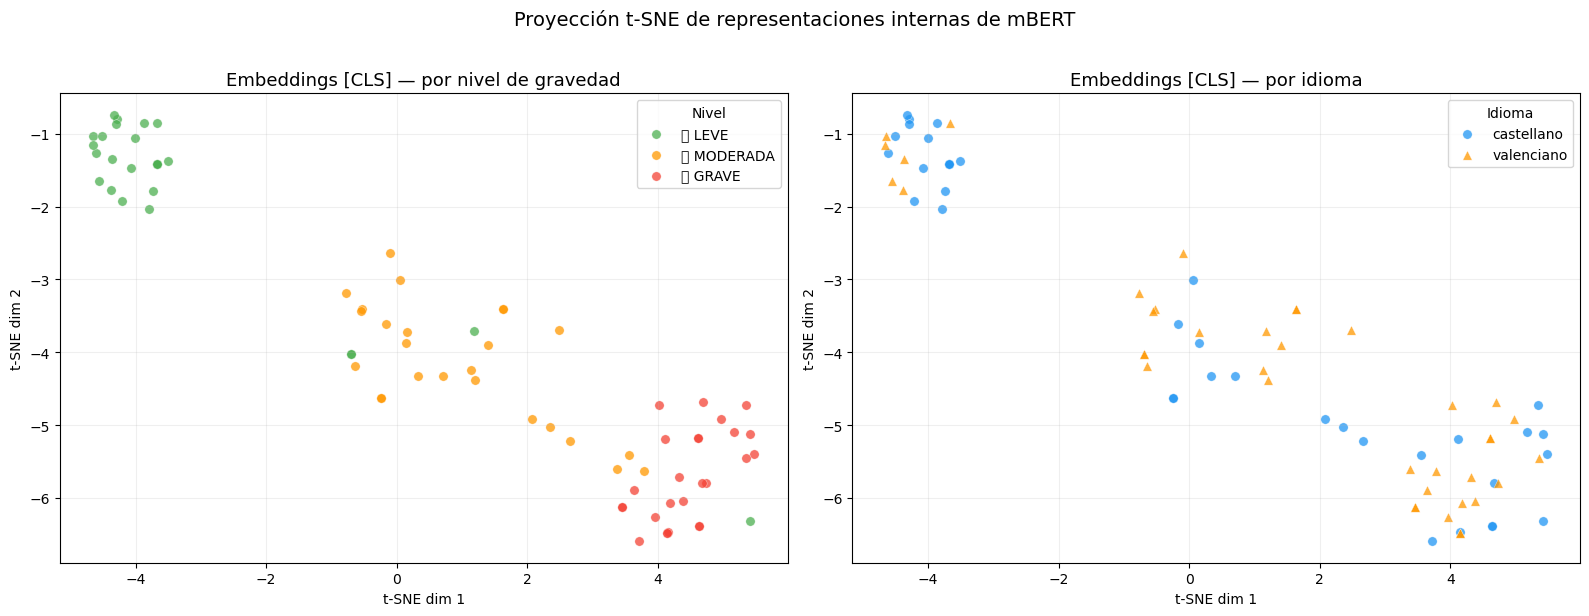


💡 Interpretación:
  · Izquierda: cúmulos separados por color → el modelo distingue los tres niveles.
  · Derecha: azul/naranja mezclados → el modelo trata igual ambos idiomas (multilingüismo real).


In [24]:
from sklearn.manifold import TSNE

def get_cls_embedding(texts, model, tokenizer, device, batch_size=32):
    """Extrae el embedding del token [CLS] para cada texto."""
    model.eval()
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch  = list(texts[i:i+batch_size])
        inputs = tokenizer(batch, return_tensors="pt", truncation=True,
                           padding=True, max_length=MAX_LEN).to(device)
        with torch.no_grad():
            outputs = model.bert(**inputs)   # accedemos al encoder, no al clasificador
        cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_emb)
    return np.vstack(embeddings)

# Usamos un subconjunto para que t-SNE sea manejable
n_viz   = min(200, len(X_test))
idx_viz = np.random.choice(len(X_test), n_viz, replace=False)

print("Extrayendo embeddings... (puede tardar ~1 min)")
embs = get_cls_embedding(X_test[idx_viz], model, tokenizer, DEVICE)

print("Proyectando con t-SNE...")
tsne    = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
embs_2d = tsne.fit_transform(embs)

df_viz    = df_test.iloc[idx_viz].copy()
df_viz["x"] = embs_2d[:, 0]
df_viz["y"] = embs_2d[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico izquierdo: coloreado por los TRES niveles de gravedad
for nivel, cfg in NIVEL_CONFIG.items():
    mask = df_viz["gravedad"] == nivel
    axes[0].scatter(
        df_viz[mask]["x"], df_viz[mask]["y"],
        c=cfg["color"], label=f"{cfg['emoji']} {cfg['nombre']}",
        alpha=0.75, s=45, edgecolors="white", linewidths=0.3
    )
axes[0].set_title("Embeddings [CLS] — por nivel de gravedad", fontsize=13)
axes[0].legend(title="Nivel")
axes[0].set_xlabel("t-SNE dim 1")
axes[0].set_ylabel("t-SNE dim 2")
axes[0].grid(alpha=0.2)

# Gráfico derecho: coloreado por idioma
for idioma, color, marker in [("castellano", "#2196F3", "o"), ("valenciano", "#FF9800", "^")]:
    mask = df_viz["idioma"] == idioma
    axes[1].scatter(
        df_viz[mask]["x"], df_viz[mask]["y"],
        c=color, label=idioma, alpha=0.75, s=45,
        edgecolors="white", linewidths=0.3, marker=marker
    )
axes[1].set_title("Embeddings [CLS] — por idioma", fontsize=13)
axes[1].legend(title="Idioma")
axes[1].set_xlabel("t-SNE dim 1")
axes[1].set_ylabel("t-SNE dim 2")
axes[1].grid(alpha=0.2)

plt.suptitle("Proyección t-SNE de representaciones internas de mBERT", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Interpretación:")
print("  · Izquierda: cúmulos separados por color → el modelo distingue los tres niveles.")
print("  · Derecha: azul/naranja mezclados → el modelo trata igual ambos idiomas (multilingüismo real).")

## 11.  Resumen y próximos pasos

### Lo que hemos conseguido

| Aspecto | Detalle |
|---------|---------|
| **Dataset** | `llamadas_emergencia.xlsx` — 504 llamadas (168 por clase, balanceado) |
| **Split** | 70% train / 15% val / 15% test con estratificación |
| **Transcripción** | Whisper `small` — español y valenciano |
| **Modelo** | `bert-base-multilingual-cased` con fine-tuning |
| **Tarea** | Clasificación triclase: 🟢 leve / 🟠 grave / 🔴 moderada |
| **Búsqueda** | Wikipedia API (es) — contexto médico automático sin clave API |
| **Métricas** | Accuracy, Precision, Recall, F1 macro + Matriz de confusión |

### Posibles mejoras

1. **Búsqueda más específica**: sustituir Wikipedia por MedlinePlus o guías clínicas del Ministerio de Sanidad para obtener protocolos de actuación directamente aplicables.

2. **Umbral ajustable para moderada**: dado que los falsos negativos en la clase más grave son los más costosos, se puede bajar el umbral:
   ```python
   THRESHOLD_MODERADA = 0.30  # Activar si P(moderada) > 30%
   ```

3. **Modelo más específico**: explorar [`PlanTL-GOB-ES/roberta-base-bne`](https://huggingface.co/PlanTL-GOB-ES/roberta-base-bne) o modelos entrenados en texto médico en español.

4. **Whisper large-v3**: mayor precisión con ruido de fondo o acentos regionales valencianos.

5. **Despliegue como API**:
   ```python
   from transformers import pipeline
   clf = pipeline("text-classification", model=OUTPUT_DIR, tokenizer=OUTPUT_DIR)
   clf("El meu fill s'està ofegant!")  # → [{'label': 'moderada', 'score': 0.9987}]
   ```

---
*Desarrollado para el proyecto de clasificación de llamadas de emergencia en la Comunitat Valenciana.*
